In [23]:
import importlib
import numpy as np
import pandas as pd
import fitsio as fio
import matplotlib.pyplot as plt

from pathlib import Path

ROOT = '/global/cfs/cdirs/desicollab/science/c3/DESI-Lensing/prelim_hscy3/gfarm.ipmu.jp/~surhud/S19ACatalogs/catalog_tracts/'
patches = ['GAMA09H', 'GAMA15H', 'VVDS', 'XMM', 'WIDE12H', 'HECTOMAP']
tracts_dir = {p: ROOT + p + '_tracts/' for p in patches}
files = {p: Path(tracts_dir[p]).glob('pz_pdf_dnnz') for p in patches}

In [47]:
tract_id = '9558'
pdffile = ROOT + 'GAMA09H_tracts/' + f'/{tract_id}_pz_pdf_dnnz.fits'
pdf = fio.FITS(pdffile)[1].read()
zfile = ROOT + 'GAMA09H_tracts/' + f'/{tract_id}_pz.fits'
z = fio.FITS(zfile)[1].read()

In [48]:
fio.FITS(zfile)[1].get_colnames()

['object_id',
 'parent_id',
 'i_ra',
 'i_dec',
 'mizuki_photoz_mean',
 'mizuki_photoz_mode',
 'mizuki_photoz_median',
 'mizuki_photoz_best',
 'mizuki_photoz_mc',
 'mizuki_photoz_conf_mean',
 'mizuki_photoz_conf_mode',
 'mizuki_photoz_conf_median',
 'mizuki_photoz_conf_best',
 'mizuki_photoz_risk_mean',
 'mizuki_photoz_risk_mode',
 'mizuki_photoz_risk_median',
 'mizuki_photoz_risk_best',
 'mizuki_photoz_std_mean',
 'mizuki_photoz_std_mode',
 'mizuki_photoz_std_median',
 'mizuki_photoz_std_best',
 'mizuki_photoz_err68_min',
 'mizuki_photoz_err68_max',
 'mizuki_photoz_err95_min',
 'mizuki_photoz_err95_max',
 'demp_photoz_mean',
 'demp_photoz_mode',
 'demp_photoz_median',
 'demp_photoz_best',
 'demp_photoz_mc',
 'demp_photoz_conf_mean',
 'demp_photoz_conf_mode',
 'demp_photoz_conf_median',
 'demp_photoz_conf_best',
 'demp_photoz_risk_mean',
 'demp_photoz_risk_mode',
 'demp_photoz_risk_median',
 'demp_photoz_risk_best',
 'demp_photoz_std_mean',
 'demp_photoz_std_mode',
 'demp_photoz_std_med

In [51]:
calibration_cut = (
        ((z['mizuki_photoz_err95_max'] - z['mizuki_photoz_err95_min']) < 2.7) &
        ((z['dnnz_photoz_err95_max'] - z['dnnz_photoz_err95_min']) < 2.7)
        )
zbin_crit = (z['dnnz_photoz_best'] > 0.6) & (z['dnnz_photoz_best'] <= 0.9)

In [52]:
print(len(z[calibration_cut & zbin_crit]))
print(len(z[zbin_crit]))
print(len(z[calibration_cut & zbin_crit])/len(z[zbin_crit]))

29696
31803
0.9337483885168066


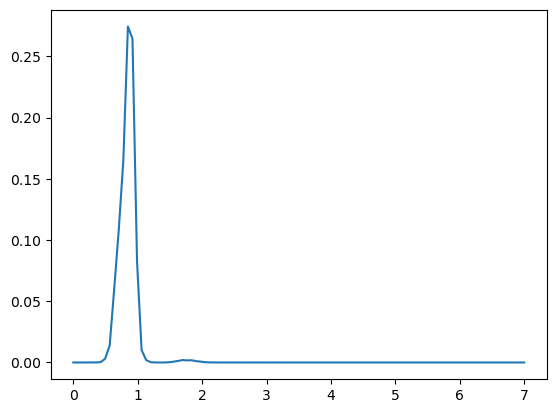

In [57]:
plt.plot(np.linspace(0, 7, 100), pdf[5][1])

In [ ]:
plt.plot()